# 🎯 Sistem Rekomendasi Karier — Data Science Pipeline

**Proyek Capstone Dicoding**  
**Tim Data Science**

---


1. ✅ Analisis permasalahan & penentuan solusi utama
2. ✅ Data Wrangling (Gathering → Assessing → Cleaning)
3. ✅ Definisi pertanyaan bisnis yang terukur
4. ✅ Exploratory Data Analysis (EDA)


---
## Analisis Permasalahan & Penentuan Solusi


### 🔍 Latar Belakang Masalah

Banyak mahasiswa atau fresh graduate di bidang teknologi mengalami kebingungan dalam menentukan jalur karier yang sesuai dengan minat dan kemampuan mereka. Tanpa panduan yang tepat, mereka berisiko memilih karier yang tidak sesuai, yang dapat berdampak pada produktivitas dan kepuasan kerja jangka panjang.

### 🎯 Solusi yang Dikembangkan

Membangun **Sistem Rekomendasi Karier berbasis Machine Learning** yang:
- Menerima input berupa jawaban kuesioner minat (skala 1–5) dari pengguna
- Memproses jawaban menggunakan model Deep Learning (MLP)
- Menghasilkan **Top-3 rekomendasi karier** yang paling sesuai

**10 Karier yang direkomendasikan:**
- Software Engineer, Data Analyst, UI/UX Designer, Digital Marketer
- Cybersecurity Analyst, Project Manager, Content Creator
- Business Analyst, Cloud Engineer, Machine Learning Engineer


---
## Definisi Pertanyaan Bisnis


Berikut pertanyaan bisnis yang dapat diukur dari proyek ini:

| # | Pertanyaan Bisnis | Metrik Pengukuran |
|---|-------------------|-------------------|
| 1 | Karier apa yang paling banyak direkomendasikan oleh sistem? | Frekuensi label karier dalam dataset |
| 2 | Apakah model dapat memprediksi karier dengan akurasi yang baik? | Accuracy, Precision, Recall, F1-Score |
| 3 | Pertanyaan (fitur) mana yang paling berpengaruh terhadap prediksi karier? | Feature importance / korelasi |
| 4 | Apakah distribusi data sudah seimbang antar karier? | Value counts per label |
| 5 | Bagaimana pola minat pengguna yang cenderung ke karier tertentu? | Rata-rata skor Q1–Q10 per karier |


---
## Data Wrangling


In [5]:
# Install library yang dibutuhkan (jalankan sekali jika belum ada)
# !pip install pandas numpy matplotlib seaborn scikit-learn


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import warnings
import joblib
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✅ Library berhasil diimport')


✅ Library berhasil diimport


### 📥 Gathering Data


In [7]:
# ── Sumber 1: Data Dummy (Generated) ──────────────────────────────────────
CAREERS = [
    'Software Engineer', 'Data Analyst', 'UI/UX Designer', 'Digital Marketer',
    'Cybersecurity Analyst', 'Project Manager', 'Content Creator',
    'Business Analyst', 'Cloud Engineer', 'Machine Learning Engineer',
]

# Profil ideal tiap karier — skala 1-5
PROFILES = {
    'Software Engineer':          [5, 3, 1, 1, 3, 1, 1, 1, 3, 3],
    'Data Analyst':               [3, 5, 1, 3, 1, 1, 1, 3, 1, 3],
    'UI/UX Designer':             [1, 1, 5, 3, 1, 1, 5, 1, 1, 1],
    'Digital Marketer':           [1, 3, 3, 5, 1, 3, 5, 3, 1, 1],
    'Cybersecurity Analyst':      [3, 3, 1, 1, 5, 1, 1, 1, 3, 1],
    'Project Manager':            [1, 3, 1, 5, 1, 5, 1, 5, 1, 1],
    'Content Creator':            [1, 1, 3, 5, 1, 1, 5, 1, 1, 1],
    'Business Analyst':           [1, 5, 1, 3, 1, 3, 1, 5, 1, 1],
    'Cloud Engineer':             [3, 1, 1, 1, 3, 1, 1, 1, 5, 3],
    'Machine Learning Engineer':  [5, 5, 1, 1, 1, 1, 1, 1, 3, 5],
}

def generate_dummy(n=1000):
    X, y = [], []
    per_class = n // len(CAREERS)
    for career, profile in PROFILES.items():
        for _ in range(per_class):
            noisy = []
            for v in profile:
                noise = np.random.choice([-2,-1,0,1,2], p=[0.05,0.20,0.50,0.20,0.05])
                noisy.append(int(np.clip(v + noise, 1, 5)))
            X.append(noisy)
            y.append(career)
    return X, y

X_dummy, y_dummy = generate_dummy(1000)
cols = [f'Q{i+1}' for i in range(10)]
df_dummy = pd.DataFrame(X_dummy, columns=cols)
df_dummy['career'] = y_dummy
df_dummy['source'] = 'dummy'
print(f'✅ Data dummy: {len(df_dummy)} baris')


✅ Data dummy: 1000 baris


In [8]:
# ── Sumber 2: Dataset Kaggle (CS Students Career Prediction) ──────────────
# Dataset: https://www.kaggle.com/datasets/devildyno/computer-science-students-career-prediction
# Upload file cs_students.csv ke Colab terlebih dahulu

df_raw = pd.read_csv('cs_students.csv')   # ganti path jika perlu
print(f'✅ Data Kaggle: {len(df_raw)} baris')
print(f'Kolom: {df_raw.columns.tolist()}')
df_raw.head()


✅ Data Kaggle: 180 baris
Kolom: ['Student ID', 'Name', 'Gender', 'Age', 'GPA', 'Major', 'Interested Domain', 'Projects', 'Future Career', 'Python', 'SQL', 'Java']


,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong


In [9]:
# ── Konversi Kaggle ke format Q1-Q10 skala 1-5 ────────────────────────────
skill_map  = {'Strong': 5, 'Average': 3, 'Weak': 1}
career_map = {
    'Software Engineer': 'Software Engineer', 'Embedded Software Engineer': 'Software Engineer',
    'Web Developer': 'Software Engineer', 'Mobile App Developer': 'Software Engineer',
    'Game Developer': 'Software Engineer', 'DevOps Engineer': 'Cloud Engineer',
    'Cloud Solutions Architect': 'Cloud Engineer', 'IoT Developer': 'Cloud Engineer',
    'Distributed Systems Engineer': 'Cloud Engineer', 'Blockchain Engineer': 'Cloud Engineer',
    'Data Scientist': 'Data Analyst', 'Data Analyst': 'Data Analyst',
    'Database Administrator': 'Data Analyst', 'Geospatial Analyst': 'Data Analyst',
    'Data Privacy Specialist': 'Data Analyst',
    'Machine Learning Engineer': 'Machine Learning Engineer',
    'Machine Learning Researcher': 'Machine Learning Engineer',
    'AI Researcher': 'Machine Learning Engineer', 'NLP Research Scientist': 'Machine Learning Engineer',
    'NLP Engineer': 'Machine Learning Engineer', 'Computer Vision Engineer': 'Machine Learning Engineer',
    'Robotics Engineer': 'Machine Learning Engineer', 'Quantum Computing Researcher': 'Machine Learning Engineer',
    'Information Security Analyst': 'Cybersecurity Analyst', 'Security Analyst': 'Cybersecurity Analyst',
    'Ethical Hacker': 'Cybersecurity Analyst', 'Digital Forensics Specialist': 'Cybersecurity Analyst',
    'UX Designer': 'UI/UX Designer', 'Graphics Programmer': 'UI/UX Designer', 'VR Developer': 'UI/UX Designer',
    'Bioinformatician': 'Business Analyst', 'Healthcare IT Specialist': 'Business Analyst',
    'SEO Specialist': 'Digital Marketer',
}

def domain_score(domain, keywords):
    for kw in keywords:
        if kw.lower() in str(domain).lower(): return 5
    return 1

def gpa_score(gpa):
    if gpa >= 3.7: return 5
    elif gpa >= 3.4: return 4
    elif gpa >= 3.0: return 3
    elif gpa >= 2.5: return 2
    else: return 1

df_kg = df_raw.copy()
df_kg['career'] = df_kg['Future Career'].map(career_map)
df_kg = df_kg.dropna(subset=['career'])

df_kg['Q1']  = df_kg['Python'].map(skill_map)
df_kg['Q2']  = df_kg['SQL'].map(skill_map)
df_kg['Q3']  = df_kg['Java'].map(skill_map)
df_kg['Q4']  = df_kg['GPA'].apply(gpa_score)
df_kg['Q5']  = df_kg['Interested Domain'].apply(lambda x: domain_score(x, ['cyber','security','forensic','network']))
df_kg['Q6']  = df_kg['GPA'].apply(lambda g: 5 if g>=3.5 else (3 if g>=3.0 else 1))
df_kg['Q7']  = df_kg['Interested Domain'].apply(lambda x: domain_score(x, ['web','design','graphics','vr','game','human']))
df_kg['Q8']  = df_kg['Interested Domain'].apply(lambda x: domain_score(x, ['data','database','business','management','mining']))
df_kg['Q9']  = df_kg['Interested Domain'].apply(lambda x: domain_score(x, ['cloud','iot','distributed','blockchain','network']))
df_kg['Q10'] = df_kg['Interested Domain'].apply(lambda x: domain_score(x, ['artificial intelligence','machine learning','nlp','computer vision','quantum','robotics']))

df_kaggle = df_kg[cols + ['career']].copy()
df_kaggle['source'] = 'kaggle'
print(f'✅ Data Kaggle setelah konversi: {len(df_kaggle)} baris')


✅ Data Kaggle setelah konversi: 180 baris


In [10]:
# ── Gabungkan kedua sumber ─────────────────────────────────────────────────
df = pd.concat([df_dummy, df_kaggle], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f'✅ Total data gabungan: {len(df)} baris')
df.head()


✅ Total data gabungan: 1180 baris


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,career,source
0,2,1,4,3,2,1,5,2,1,3,UI/UX Designer,dummy
1,5,5,1,1,3,1,1,1,2,2,Software Engineer,dummy
2,5,4,1,1,1,1,1,1,1,5,Machine Learning Engineer,dummy
3,1,2,1,3,2,4,1,5,1,1,Project Manager,dummy
4,1,1,3,3,1,2,5,2,2,1,UI/UX Designer,dummy


### 🔎 Assessing Data


In [11]:
print('=== Info Dataset ===')
print(df.info())
print('\n=== Statistik Deskriptif ===')
print(df.describe())


=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1180 entries, 0 to 1179
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q1      1180 non-null   int64 
 1   Q2      1180 non-null   int64 
 2   Q3      1180 non-null   int64 
 3   Q4      1180 non-null   int64 
 4   Q5      1180 non-null   int64 
 5   Q6      1180 non-null   int64 
 6   Q7      1180 non-null   int64 
 7   Q8      1180 non-null   int64 
 8   Q9      1180 non-null   int64 
 9   Q10     1180 non-null   int64 
 10  career  1180 non-null   object
 11  source  1180 non-null   object
dtypes: int64(10), object(2)
memory usage: 110.8+ KB
None

=== Statistik Deskriptif ===
                Q1           Q2           Q3           Q4           Q5  \
count  1180.000000  1180.000000  1180.000000  1180.000000  1180.000000   
mean      2.560169     3.076271     2.131356     3.042373     1.892373   
std       1.547859     1.506879     1.432283     1.571556 

In [12]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Duplikasi ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

print('\n=== Range nilai Q1-Q10 ===')
for col in cols:
    print(f'{col}: min={df[col].min()}, max={df[col].max()}, unique={sorted(df[col].unique())}')


=== Missing Values ===
Q1        0
Q2        0
Q3        0
Q4        0
Q5        0
Q6        0
Q7        0
Q8        0
Q9        0
Q10       0
career    0
source    0
dtype: int64

=== Duplikasi ===
Jumlah baris duplikat: 186

=== Range nilai Q1-Q10 ===
Q1: min=1, max=5, unique=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Q2: min=1, max=5, unique=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Q3: min=1, max=5, unique=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Q4: min=1, max=5, unique=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Q5: min=1, max=5, unique=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Q6: min=1, max=5, unique=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Q7: min=1, max=5, unique=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Q8: min=1, max=5, unique=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Q9: min=1, max=5, 

In [13]:
print('=== Distribusi Label Karier ===')
print(df['career'].value_counts())


=== Distribusi Label Karier ===
career
Software Engineer            155
Machine Learning Engineer    136
Data Analyst                 132
Cloud Engineer               120
Cybersecurity Analyst        120
UI/UX Designer               112
Business Analyst             104
Digital Marketer             101
Content Creator              100
Project Manager              100
Name: count, dtype: int64


### 🧹 Cleaning Data


In [14]:
# Hapus duplikat jika ada
before = len(df)
df = df.drop_duplicates()
print(f'Baris dihapus karena duplikat: {before - len(df)}')

# Hapus missing values jika ada
before = len(df)
df = df.dropna()
print(f'Baris dihapus karena missing: {before - len(df)}')

# Pastikan nilai Q1-Q10 dalam rentang 1-5
for col in cols:
    df[col] = df[col].clip(1, 5)

# Label Encoding
le = LabelEncoder()
df['career_encoded'] = le.fit_transform(df['career'])
joblib.dump(le, 'label_encoder.pkl') # Simpan agar bisa dipakai saat prediksi

# Scaling
scaler = MinMaxScaler()
df[cols] = scaler.fit_transform(df[cols])

# Reset index
df = df.reset_index(drop=True)
print(f'\n✅ Data bersih: {len(df)} baris siap digunakan')


Baris dihapus karena duplikat: 186
Baris dihapus karena missing: 0

✅ Data bersih: 994 baris siap digunakan


In [15]:
# Simpan dataset bersih
df_clean = df.drop(columns=['source'])
df_clean.to_csv('career_final_dataset.csv', index=False)
print('✅ Dataset bersih disimpan: career_final_dataset.csv')


✅ Dataset bersih disimpan: career_final_dataset.csv


---
## Exploratory Data Analysis (EDA)


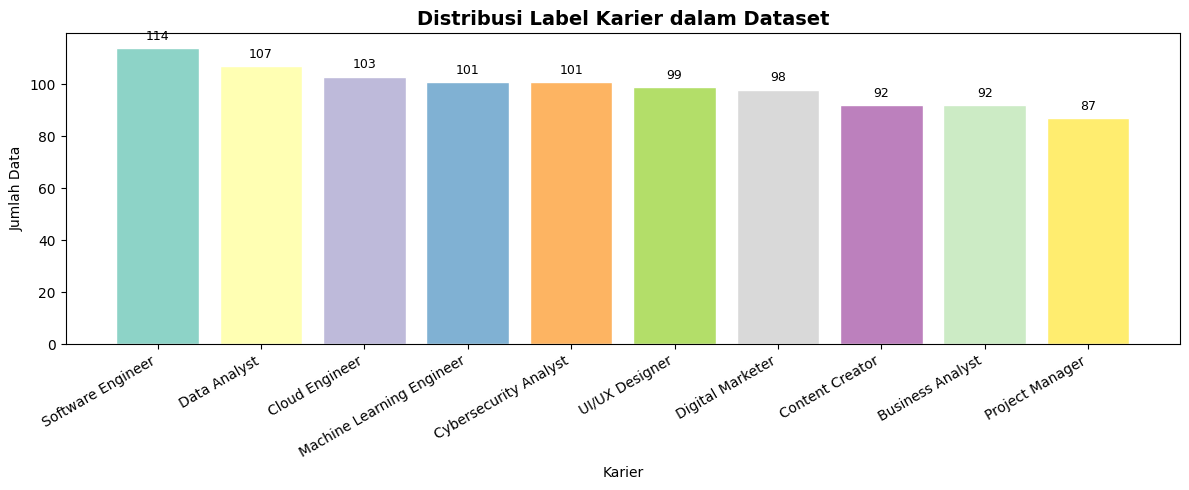

In [16]:
# ── EDA 1: Distribusi Label Karier ────────────────────────────────────────
plt.figure(figsize=(12, 5))
career_counts = df['career'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(career_counts)))
bars = plt.bar(career_counts.index, career_counts.values, color=colors, edgecolor='white')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.title('Distribusi Label Karier dalam Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Karier')
plt.ylabel('Jumlah Data')
for bar, val in zip(bars, career_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


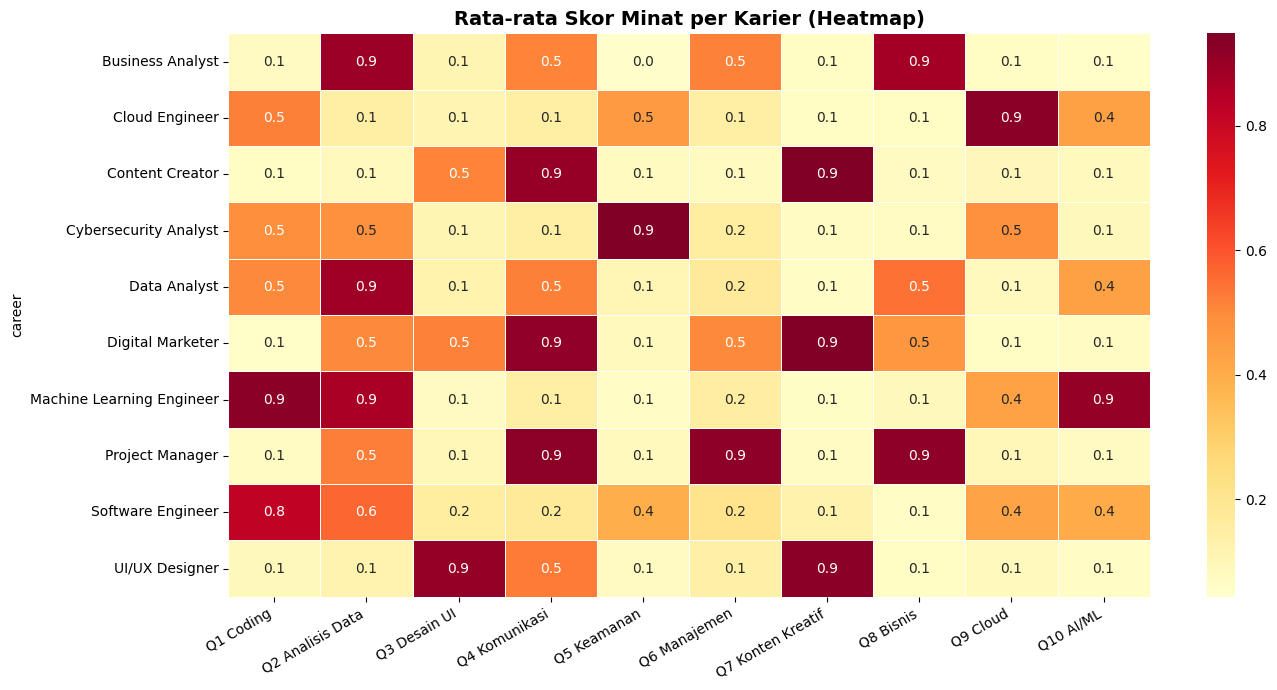

In [17]:
# ── EDA 2: Rata-rata Skor Per Pertanyaan Per Karier ───────────────────────
QUESTIONS = [
    'Q1 Coding', 'Q2 Analisis Data', 'Q3 Desain UI',
    'Q4 Komunikasi', 'Q5 Keamanan', 'Q6 Manajemen',
    'Q7 Konten Kreatif', 'Q8 Bisnis', 'Q9 Cloud', 'Q10 AI/ML'
]

mean_by_career = df.groupby('career')[cols].mean()

plt.figure(figsize=(14, 7))
sns.heatmap(
    mean_by_career, annot=True, fmt='.1f',
    cmap='YlOrRd', linewidths=0.5,
    xticklabels=QUESTIONS, yticklabels=mean_by_career.index
)
plt.title('Rata-rata Skor Minat per Karier (Heatmap)', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


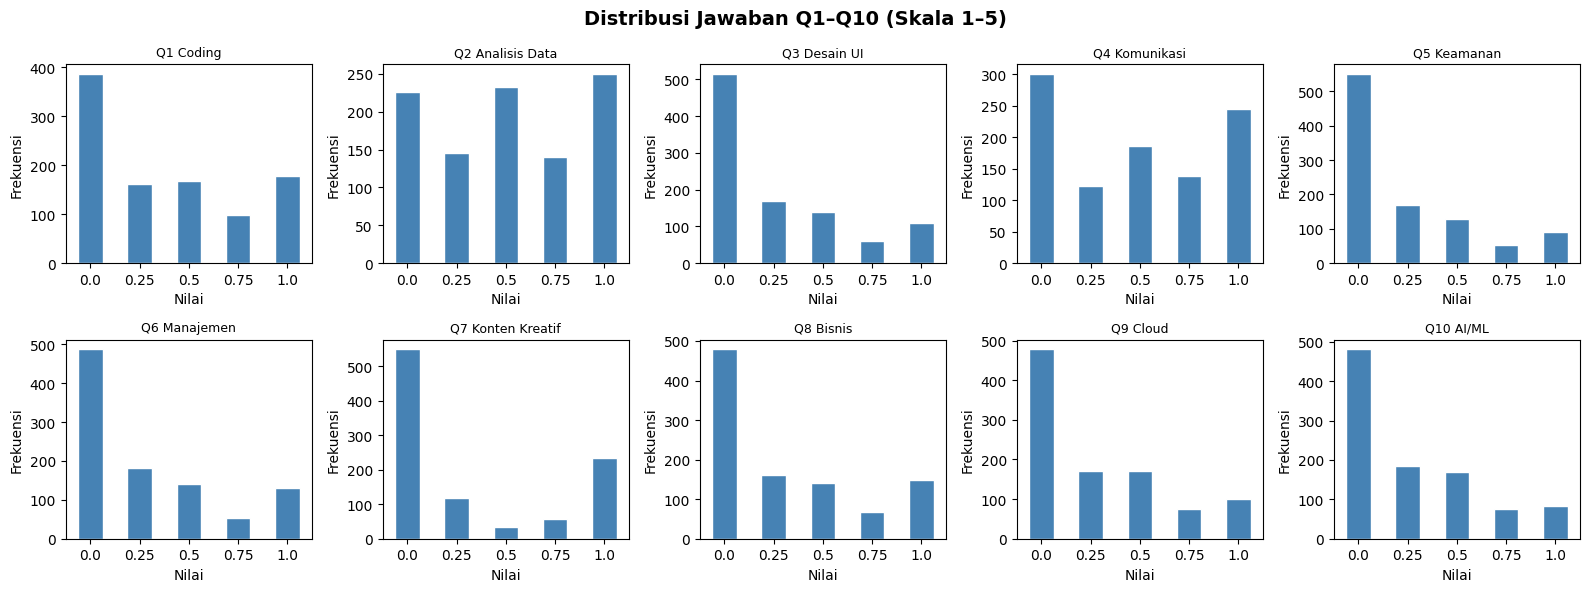

In [18]:
# ── EDA 3: Distribusi Nilai Q1-Q10 (Histogram) ───────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Distribusi Jawaban Q1–Q10 (Skala 1–5)', fontsize=14, fontweight='bold')

for i, (ax, col, q) in enumerate(zip(axes.flatten(), cols, QUESTIONS)):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(q, fontsize=9)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


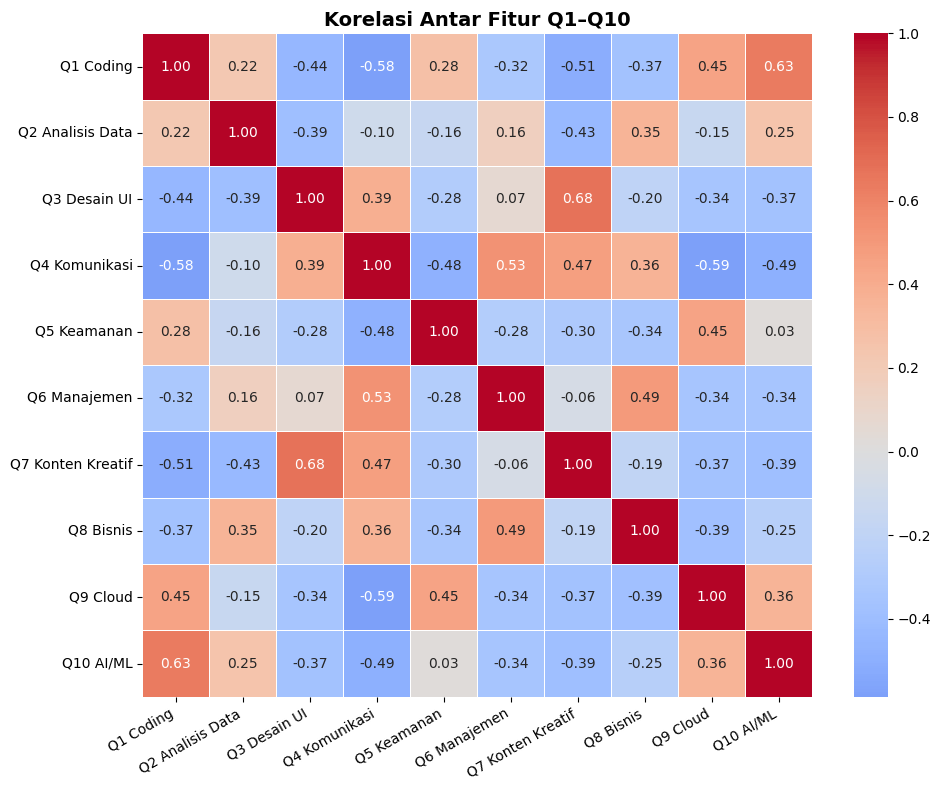

In [19]:
# ── EDA 4: Korelasi Antar Fitur ───────────────────────────────────────────
plt.figure(figsize=(10, 8))
corr = df[cols].corr()
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5,
    xticklabels=QUESTIONS, yticklabels=QUESTIONS
)
plt.title('Korelasi Antar Fitur Q1–Q10', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


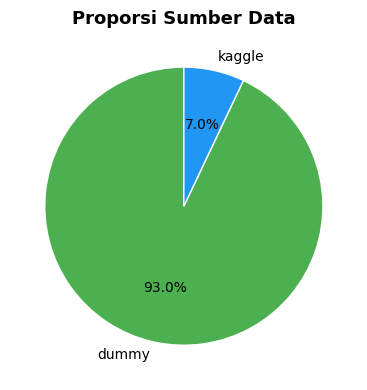

Data dummy : 924 baris
Data kaggle: 70 baris


In [20]:
# ── EDA 5: Perbandingan Sumber Data ──────────────────────────────────────
plt.figure(figsize=(6, 4))
source_counts = df['source'].value_counts()
plt.pie(source_counts.values, labels=source_counts.index,
        autopct='%1.1f%%', colors=['#4CAF50', '#2196F3'],
        startangle=90, wedgeprops={'edgecolor': 'white'})
plt.title('Proporsi Sumber Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Data dummy : {source_counts.get("dummy", 0)} baris')
print(f'Data kaggle: {source_counts.get("kaggle", 0)} baris')


In [21]:
# ── EDA 6: Insight Ringkasan ──────────────────────────────────────────────
print('=' * 55)
print('           📊 RINGKASAN EDA')
print('=' * 55)
print(f'Total data        : {len(df)} baris')
print(f'Jumlah fitur      : {len(cols)} pertanyaan (Q1–Q10)')
print(f'Jumlah kelas      : {df["career"].nunique()} karier')
print(f'Skala jawaban     : 1–5')
print(f'Missing values    : {df.isnull().sum().sum()}')
print(f'Duplikasi         : {df.duplicated().sum()}')
print(f'Karier terbanyak  : {df["career"].value_counts().idxmax()}')
print(f'Karier tersedikit : {df["career"].value_counts().idxmin()}')
print('=' * 55)
print('✅ Data siap diteruskan ke tahap modeling!')


           📊 RINGKASAN EDA
Total data        : 994 baris
Jumlah fitur      : 10 pertanyaan (Q1–Q10)
Jumlah kelas      : 10 karier
Skala jawaban     : 1–5
Missing values    : 0
Duplikasi         : 0
Karier terbanyak  : Software Engineer
Karier tersedikit : Project Manager
✅ Data siap diteruskan ke tahap modeling!
